In [1]:
import numpy as np
import matplotlib.pyplot as plt

from ripser import ripser
from persim import plot_diagrams

from gtda.diagrams import PersistenceEntropy, PersistenceLandscape

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

import gudhi as gd

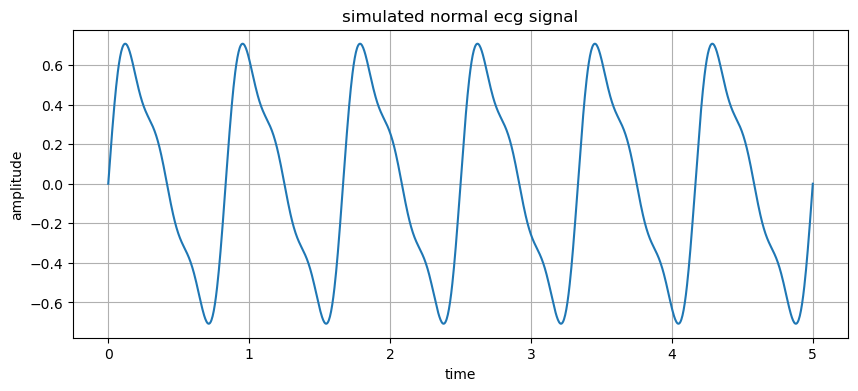

In [2]:
def generate_normal_ecg(duration=5, fs=250):
    t = np.linspace(0, duration, int(duration * fs))
    ecg = (0.6 * np.sin(2 * np.pi * 1.2 * t) +
           0.2 * np.sin(2 * np.pi * 2.4 * t) +
           0.1 * np.sin(2 * np.pi * 3.6 * t))
    return t, ecg

t_normal, ecg_normal = generate_normal_ecg()

plt.figure(figsize=(10, 4))
plt.plot(t_normal, ecg_normal)
plt.title("simulated normal ecg signal")
plt.xlabel("time")
plt.ylabel("amplitude")
plt.grid(True)
plt.show()

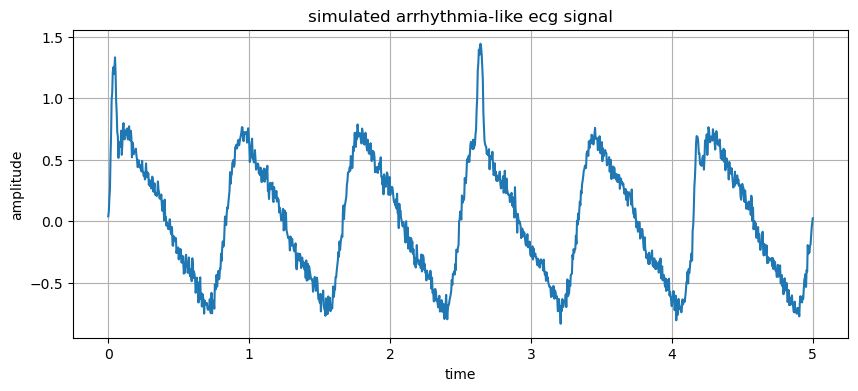

In [3]:
def generate_arrhythmia_ecg(duration=5, fs=250):
    t, clean_ecg = generate_normal_ecg(duration, fs)
    jitter = np.random.normal(scale=0.05, size=clean_ecg.shape)
    noisy_ecg = clean_ecg + jitter
    for _ in range(3):
        idx = np.random.randint(0, len(noisy_ecg) - 20)
        noisy_ecg[idx:idx+20] += np.hanning(20) * np.random.uniform(0.5, 1.0)
    return t, noisy_ecg

t_arrhythmia, ecg_arrhythmia = generate_arrhythmia_ecg()

plt.figure(figsize=(10, 4))
plt.plot(t_arrhythmia, ecg_arrhythmia)
plt.title("simulated arrhythmia-like ecg signal")
plt.xlabel("time")
plt.ylabel("amplitude")
plt.grid(True)
plt.show()

In [4]:
def takens_embedding(x, m=3, tau=10):
    N = len(x)
    return np.array([x[i:i+m*tau:tau] 
                     for i in range(N-(m-1)*tau)])

embedded_normal = takens_embedding(ecg_normal, m=3, tau=10)
embedded_arrhythmia = takens_embedding(ecg_arrhythmia, m=3, tau=10)

print(embedded_normal.shape)
print(embedded_arrhythmia.shape)

(1230, 3)
(1230, 3)


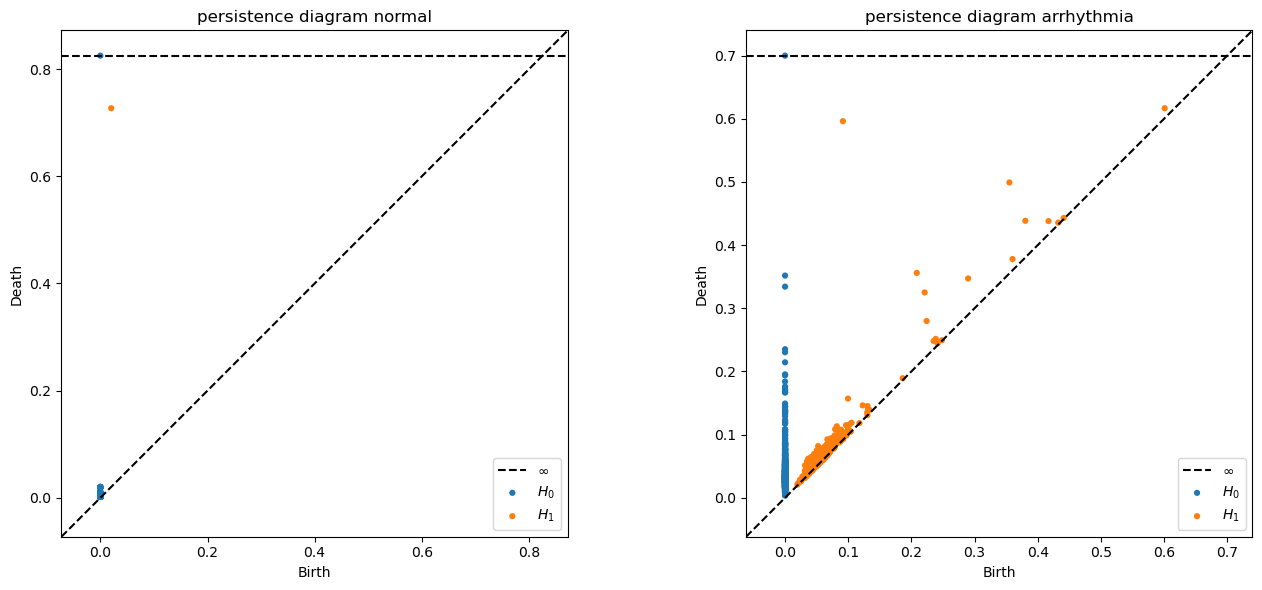

In [5]:
dgms_normal = ripser(embedded_normal, maxdim=1)['dgms']
dgms_arrhythmia = ripser(embedded_arrhythmia, maxdim=1)['dgms']

plt.figure(figsize=(14,6))

plt.subplot(1,2,1)
plot_diagrams(dgms_normal, show=False)
plt.title("persistence diagram normal")

plt.subplot(1,2,2)
plot_diagrams(dgms_arrhythmia, show=False)
plt.title("persistence diagram arrhythmia")

plt.tight_layout()
plt.show()

# Simplex Tree

1230
19067246


C:\Users\91829\AppData\Roaming\Python\Python312\site-packages\gudhi\persistence_graphical_tools.py:129: UserWarning: usetex mode requires TeX.
  warnings.warn("usetex mode requires TeX.")


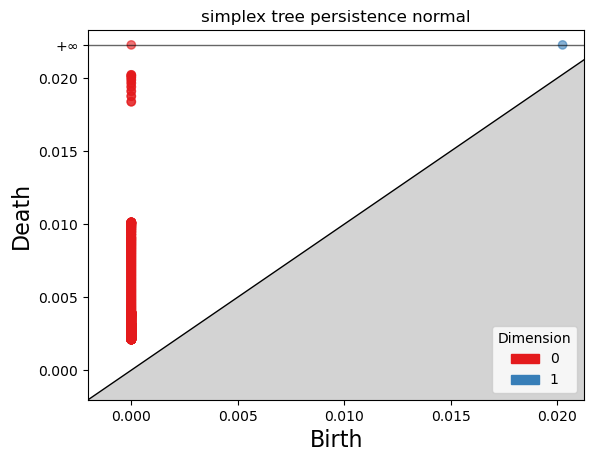

In [6]:
rips = gd.RipsComplex(points=embedded_normal, max_edge_length=0.5)
simplex_tree = rips.create_simplex_tree(max_dimension=2)

print(simplex_tree.num_vertices())
print(simplex_tree.num_simplices())

diag_simplex = simplex_tree.persistence()

gd.plot_persistence_diagram(diag_simplex)
plt.title("simplex tree persistence normal")
plt.show()

In [21]:
print("first simplices in simplex tree:\n")

count = 0
for simplex, filtration in simplex_tree.get_filtration():
    dim = len(simplex) - 1
    print("simplex:", simplex,
          "dimension:", dim,
          "birth:", round(filtration, 4))
    count += 1
    if count >= 20:
        break

first simplices in simplex tree:

simplex: [0] dimension: 0 birth: 0.0
simplex: [1] dimension: 0 birth: 0.0
simplex: [2] dimension: 0 birth: 0.0
simplex: [3] dimension: 0 birth: 0.0
simplex: [4] dimension: 0 birth: 0.0
simplex: [5] dimension: 0 birth: 0.0
simplex: [6] dimension: 0 birth: 0.0
simplex: [7] dimension: 0 birth: 0.0
simplex: [8] dimension: 0 birth: 0.0
simplex: [9] dimension: 0 birth: 0.0
simplex: [10] dimension: 0 birth: 0.0
simplex: [11] dimension: 0 birth: 0.0
simplex: [12] dimension: 0 birth: 0.0
simplex: [13] dimension: 0 birth: 0.0
simplex: [14] dimension: 0 birth: 0.0
simplex: [15] dimension: 0 birth: 0.0
simplex: [16] dimension: 0 birth: 0.0
simplex: [17] dimension: 0 birth: 0.0
simplex: [18] dimension: 0 birth: 0.0
simplex: [19] dimension: 0 birth: 0.0


In [24]:
from collections import Counter

dim_counter = Counter()

for simplex, filtration in simplex_tree.get_skeleton(2):
    dim = len(simplex) - 1
    dim_counter[dim] += 1

print("simplex count by dimension (up to dim 2):")
for dim in sorted(dim_counter):
    print("dimension", dim, ":", dim_counter[dim])

simplex count by dimension (up to dim 2):
dimension 0 : 1248
dimension 1 : 317015
dimension 2 : 44172256


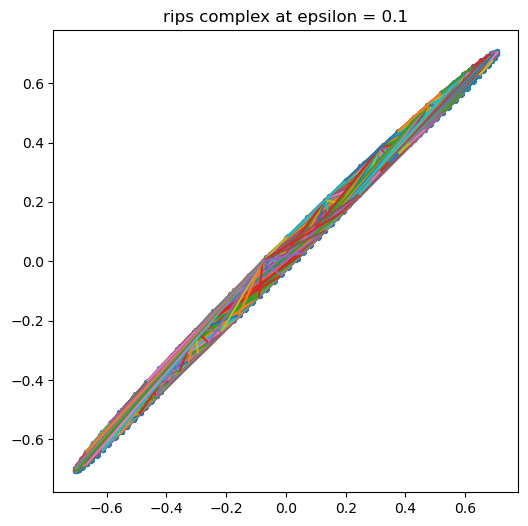

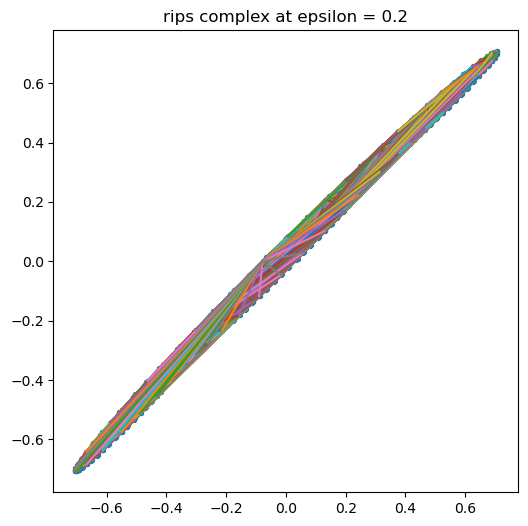

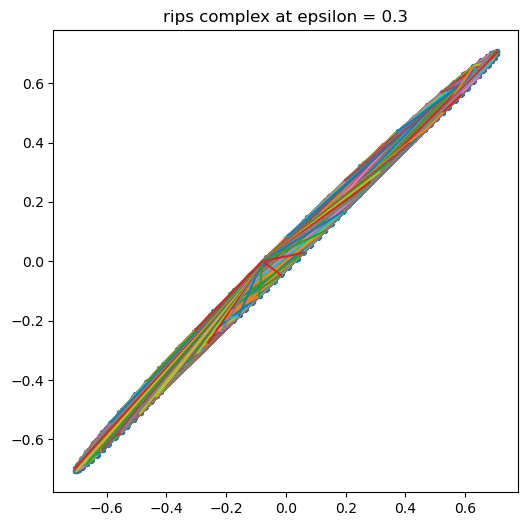

In [25]:
pc = embedded_normal[:, :2]

max_points_plot = 300
if pc.shape[0] > max_points_plot:
    idx = np.linspace(0, pc.shape[0]-1, max_points_plot).astype(int)
    pc = pc[idx]

skeleton = list(simplex_tree.get_skeleton(2))

eps_values = [0.1, 0.2, 0.3]

for eps in eps_values:
    plt.figure(figsize=(6,6))
    plt.scatter(pc[:,0], pc[:,1], s=8)

    for simplex, filtration in skeleton:
        if filtration <= eps:
            if len(simplex) == 2:
                i, j = simplex
                if i < len(pc) and j < len(pc):
                    plt.plot([pc[i,0], pc[j,0]],
                             [pc[i,1], pc[j,1]])
            elif len(simplex) == 3:
                i, j, k = simplex
                if i < len(pc) and j < len(pc) and k < len(pc):
                    pts = pc[[i, j, k]]
                    plt.fill(pts[:,0], pts[:,1], alpha=0.1)

    plt.title("rips complex at epsilon = " + str(eps))
    plt.show()

In [26]:
simplex_tree.compute_persistence()
pairs = simplex_tree.persistence_pairs()

print("first few h1 persistence pairs:\n")

count = 0
for creator, destroyer in pairs:
    if len(creator) == 2 and destroyer is not None:
        print("loop created by edge:", creator)
        print("filled by triangle:", destroyer)
        print()
        count += 1
        if count >= 5:
            break

first few h1 persistence pairs:

loop created by edge: [992, 607]
filled by triangle: [992, 815, 607]

loop created by edge: [640, 255]
filled by triangle: [640, 432, 255]

loop created by edge: [399, 159]
filled by triangle: [1200, 607, 399]

loop created by edge: [1088, 848]
filled by triangle: [1088, 848, 47]

loop created by edge: [1091, 222]
filled by triangle: [1091, 222, 50]



# Extended Persistence

In [7]:
max_points = 250

def subsample(pc):
    if pc.shape[0] > max_points:
        idx = np.linspace(0, pc.shape[0]-1, max_points).astype(int)
        return pc[idx]
    return pc

embedded_normal = subsample(embedded_normal)
embedded_arrhythmia = subsample(embedded_arrhythmia)

In [8]:
def compute_extended_persistence(point_cloud, distance_threshold=0.2):
    
    st = gd.SimplexTree()

    for i, pt in enumerate(point_cloud):
        st.insert([i], filtration=pt[0])

    for i in range(len(point_cloud)):
        for j in range(i+1, len(point_cloud)):
            dist = np.linalg.norm(point_cloud[i] - point_cloud[j])
            if dist <= distance_threshold:
                st.insert([i, j], 
                          filtration=max(point_cloud[i][0],
                                         point_cloud[j][0]))

    st.make_filtration_non_decreasing()
    st.extend_filtration()

    diag_ext = st.extended_persistence()

    return diag_ext

diag_ext_normal = compute_extended_persistence(embedded_normal)
diag_ext_arrhythmia = compute_extended_persistence(embedded_arrhythmia)

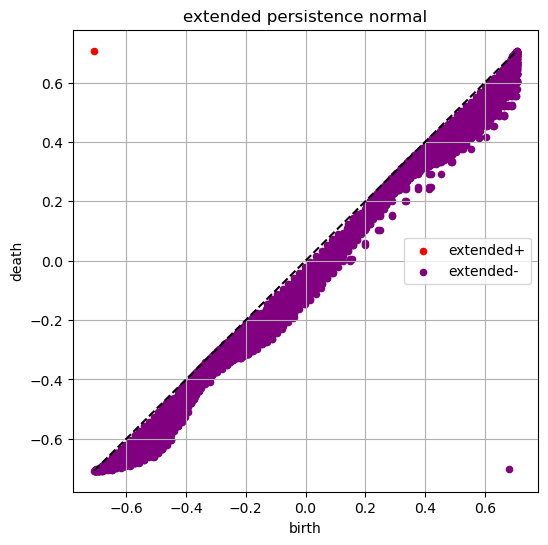

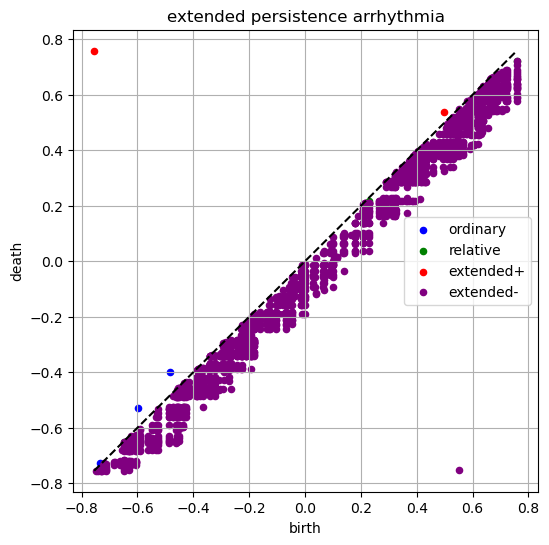

In [9]:
def plot_extended(diag_ext, title):

    blocks = diag_ext
    block_names = ["ordinary", "relative", "extended+", "extended-"]

    plt.figure(figsize=(6,6))

    colors = ['blue', 'green', 'red', 'purple']

    for block_index, block in enumerate(blocks):
        births = []
        deaths = []

        for dim, (birth, death) in block:
            if death != float('inf'):
                births.append(birth)
                deaths.append(death)

        if len(births) > 0:
            plt.scatter(births, deaths,
                        color=colors[block_index],
                        label=block_names[block_index],
                        s=20)

    all_vals = []
    for block in blocks:
        for dim, (birth, death) in block:
            if death != float('inf'):
                all_vals.append(birth)
                all_vals.append(death)

    if len(all_vals) > 0:
        min_val = min(all_vals)
        max_val = max(all_vals)
        plt.plot([min_val, max_val],
                 [min_val, max_val], 'k--')

    plt.xlabel("birth")
    plt.ylabel("death")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

plot_extended(diag_ext_normal, "extended persistence normal")
plot_extended(diag_ext_arrhythmia, "extended persistence arrhythmia")

# Choosing optimal 'tau' and 'm'

In [10]:
from sklearn.metrics import mutual_info_score

def autocorrelation_tau(x, max_lag=100):
    x = x - np.mean(x)
    autocorr = [np.correlate(x[:-lag], x[lag:])[0] 
                if lag > 0 else 1 
                for lag in range(max_lag)]
    autocorr = np.array(autocorr)
    autocorr /= autocorr[0]
    for i in range(1, len(autocorr)):
        if autocorr[i] <= 0:
            return i
    return 1

def average_mutual_information_tau(x, max_lag=100, bins=32):
    ami = []
    x_binned = np.digitize(x, 
                           np.histogram(x, bins=bins)[1])
    for lag in range(1, max_lag):
        x1 = x_binned[:-lag]
        x2 = x_binned[lag:]
        ami.append(mutual_info_score(x1, x2))
    ami = np.array(ami)
    for i in range(1, len(ami)-1):
        if ami[i] < ami[i-1] and ami[i] < ami[i+1]:
            return i+1
    return 1

tau_auto = autocorrelation_tau(ecg_normal)
tau_ami = average_mutual_information_tau(ecg_normal)

tau = tau_ami

print("tau autocorrelation:", tau_auto)
print("tau ami:", tau_ami)
print("chosen tau:", tau)

tau autocorrelation: 51
tau ami: 2
chosen tau: 2


In [12]:
from sklearn.neighbors import NearestNeighbors

def false_nearest_neighbors(x, tau, max_dim=10, threshold=0.1):
    fnn_percentages = []

    for m in range(1, max_dim):
        embedded_m = takens_embedding(x, m=m, tau=tau)
        embedded_m1 = takens_embedding(x, m=m+1, tau=tau)

        min_len = min(len(embedded_m), len(embedded_m1))
        embedded_m = embedded_m[:min_len]
        embedded_m1 = embedded_m1[:min_len]

        nbrs = NearestNeighbors(n_neighbors=2).fit(embedded_m)
        distances, indices = nbrs.kneighbors(embedded_m)

        false_count = 0
        total = min_len

        for i in range(total):
            neighbor_index = indices[i,1]

            if neighbor_index >= min_len:
                continue

            dist_m = distances[i,1]

            if dist_m == 0:
                continue

            dist_m1 = np.linalg.norm(
                embedded_m1[i] - embedded_m1[neighbor_index]
            )

            if abs(dist_m1 - dist_m) / dist_m > 10:
                false_count += 1

        fnn_percentages.append(false_count / total)

    for i, perc in enumerate(fnn_percentages):
        if perc < threshold:
            return i+1

    return max_dim

m = false_nearest_neighbors(ecg_normal, tau)

print("chosen embedding dimension m:", m)

chosen embedding dimension m: 2


In [13]:
embedded_normal = takens_embedding(ecg_normal, m=m, tau=tau)
embedded_arrhythmia = takens_embedding(ecg_arrhythmia, m=m, tau=tau)

In [14]:
print(embedded_normal.shape)
print(embedded_arrhythmia.shape)

(1248, 2)
(1248, 2)


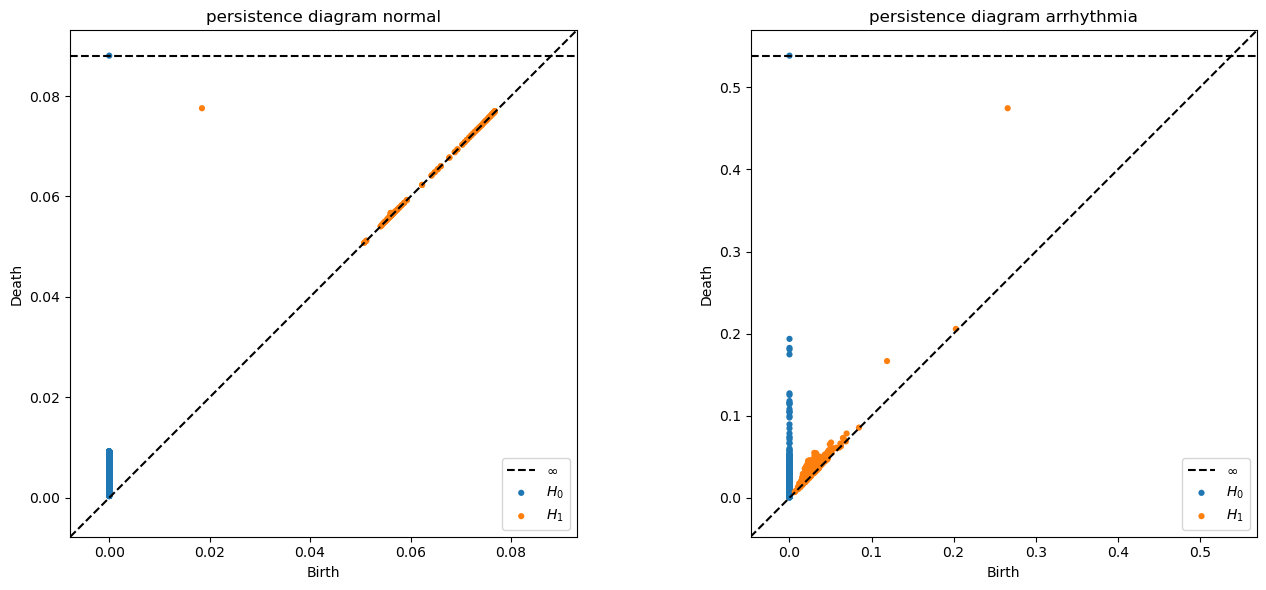

In [15]:
dgms_normal = ripser(embedded_normal, maxdim=1)['dgms']
dgms_arrhythmia = ripser(embedded_arrhythmia, maxdim=1)['dgms']

plt.figure(figsize=(14,6))

plt.subplot(1,2,1)
plot_diagrams(dgms_normal, show=False)
plt.title("persistence diagram normal")

plt.subplot(1,2,2)
plot_diagrams(dgms_arrhythmia, show=False)
plt.title("persistence diagram arrhythmia")

plt.tight_layout()
plt.show()

1248
44490519


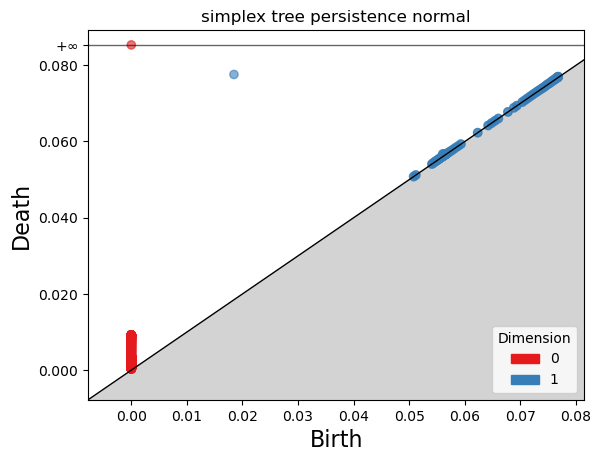

In [16]:
rips = gd.RipsComplex(points=embedded_normal, max_edge_length=0.5)
simplex_tree = rips.create_simplex_tree(max_dimension=2)

print(simplex_tree.num_vertices())
print(simplex_tree.num_simplices())

diag_simplex = simplex_tree.persistence()

gd.plot_persistence_diagram(diag_simplex)
plt.title("simplex tree persistence normal")
plt.show()

In [17]:
max_points = 250

def subsample(pc):
    if pc.shape[0] > max_points:
        idx = np.linspace(0, pc.shape[0]-1, max_points).astype(int)
        return pc[idx]
    return pc

embedded_normal = subsample(embedded_normal)
embedded_arrhythmia = subsample(embedded_arrhythmia)

In [18]:
diag_ext_normal = compute_extended_persistence(embedded_normal)
diag_ext_arrhythmia = compute_extended_persistence(embedded_arrhythmia)

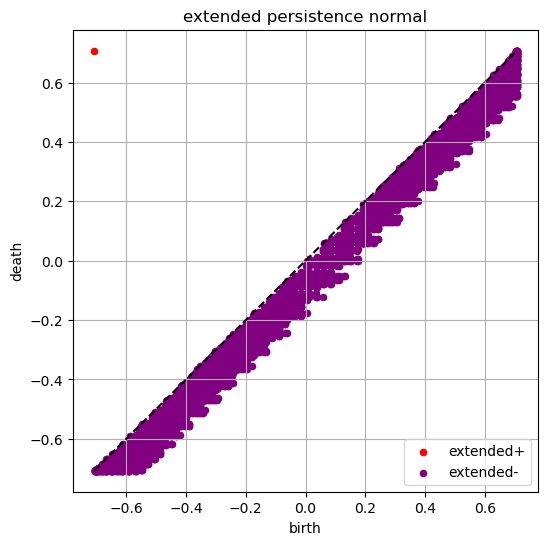

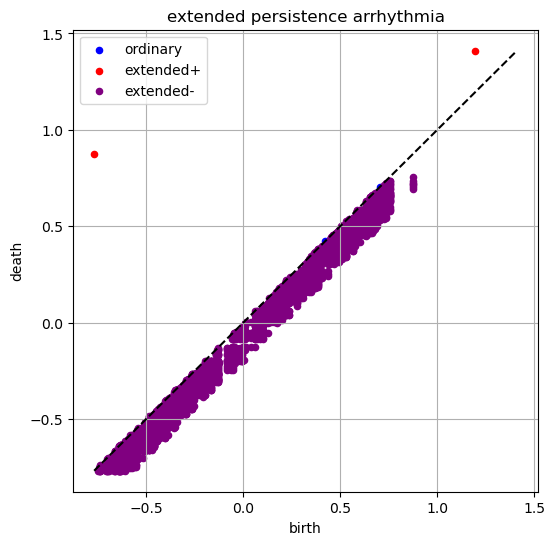

In [19]:
plot_extended(diag_ext_normal, "extended persistence normal")
plot_extended(diag_ext_arrhythmia, "extended persistence arrhythmia")